# Part1 and Part 2 using hard coded data.


Cross-Validation Results (Correlation):
Fold       Correlation    
1          -1.0000        
2          -0.2384        

Average Correlation: -0.6192        

Simplified 'Prediction' Evaluation:
Mean Squared Error: 25.7341
R-squared: -2936813.0203


<ipython-input-10-0813b67c5297>:79: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  all_predictions.fillna(method='ffill', inplace=True)
<ipython-input-10-0813b67c5297>:79: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  all_predictions.fillna(method='ffill', inplace=True)


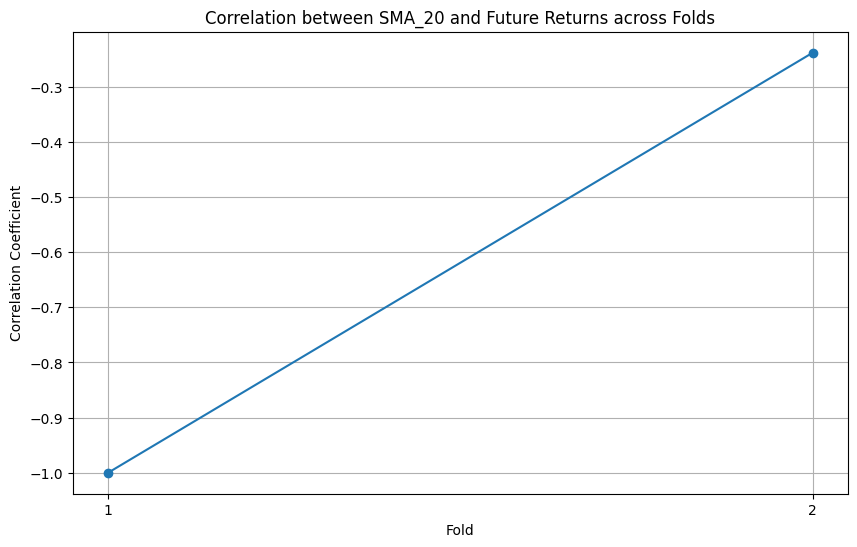


Sample of hardcoded tweets:
                   timestamp       username  \
0  2025-04-26 09:00:00+00:00     BullishBob   
1  2025-04-26 09:05:00+00:00  BearishTrader   
2  2025-04-26 09:10:00+00:00    NeutralNews   
3  2025-04-26 09:15:00+00:00       Optimist   
4  2025-04-26 09:20:00+00:00        Skeptic   

                                         tweet  
0                $AAPL looking good! #AAPL buy  
1       Selling $AAPL on this news. #AAPL sell  
2             $AAPL price steady. #AAPL market  
3  I'm very positive about $AAPL future! #AAPL  
4    Doubtful about $AAPL rally. #AAPL caution  

Tweets with hardcoded sentiment scores:
                   timestamp       username  \
0  2025-04-26 09:00:00+00:00     BullishBob   
1  2025-04-26 09:05:00+00:00  BearishTrader   
2  2025-04-26 09:10:00+00:00    NeutralNews   
3  2025-04-26 09:15:00+00:00       Optimist   
4  2025-04-26 09:20:00+00:00        Skeptic   

                                         tweet  \
0                $AA

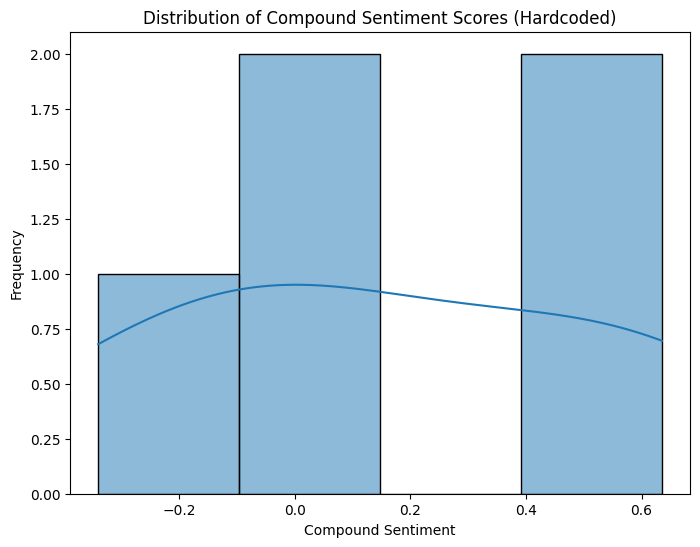

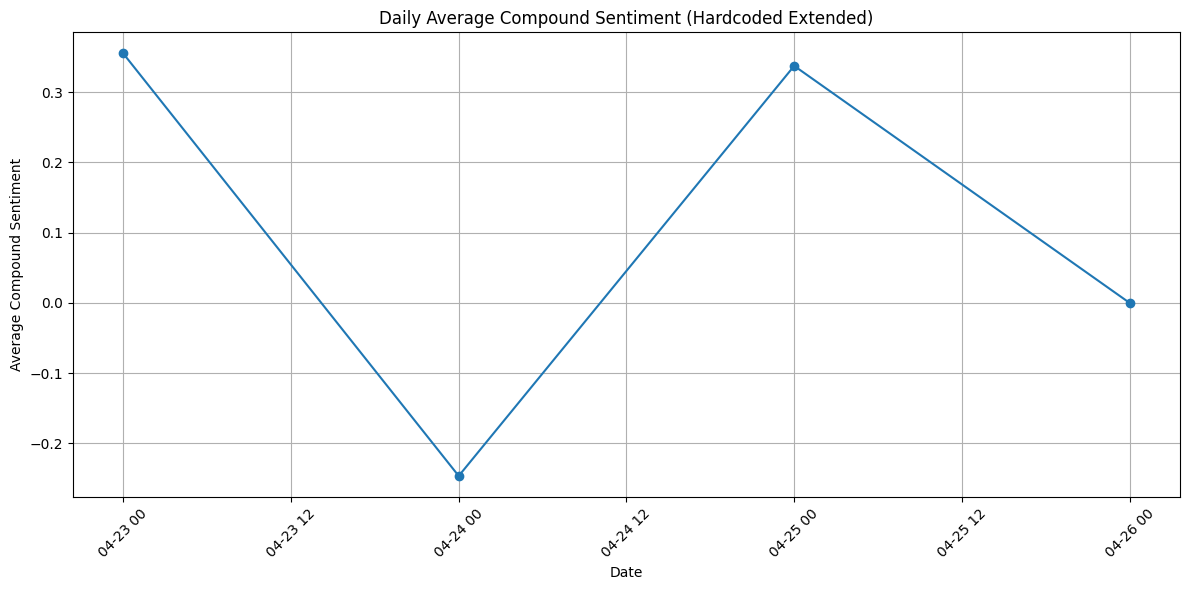

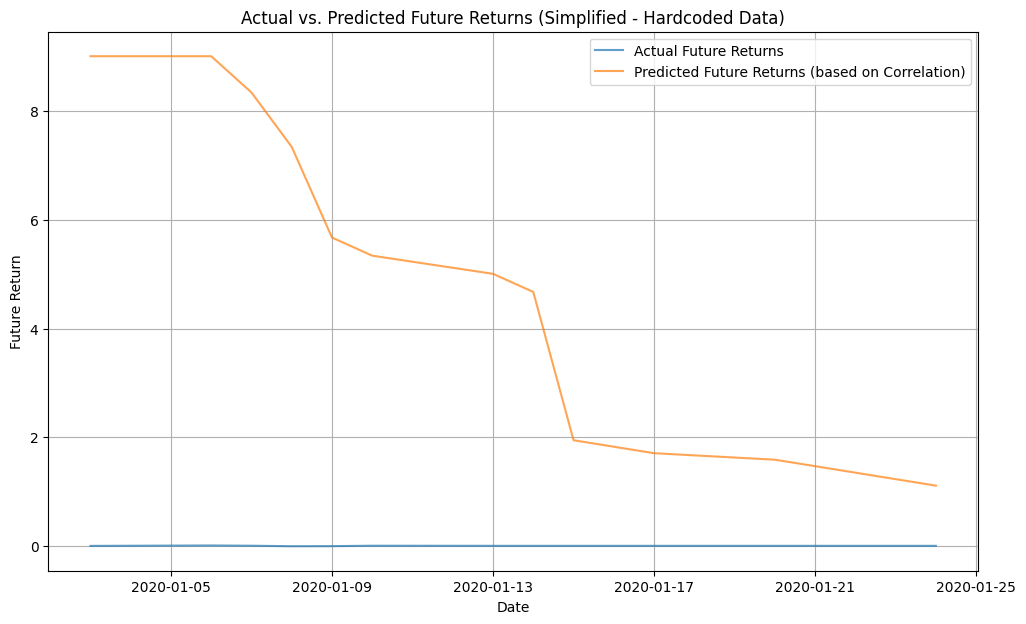

In [10]:
!pip install ta
!pip install snscrape
!pip install yfinance
!pip install nltk

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import ta
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import snscrape.modules.twitter as sntwitter
import seaborn as sns # Make sure to import seaborn

 # Download VADER lexicon for sentiment analysis (run once)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except nltk.downloader.DownloadError:
    print("(1) Downloading VADER lexicon...")
    nltk.download('vader_lexicon')
    print(True)

# Part 1: Stock Price Analysis and Prediction with SMA
 # 1. Hardcoded IVV data (first few rows for demonstration)
hardcoded_data = {
    'Open': [320.00, 321.50, 322.00, 321.00, 323.00, 324.00, 325.00, 324.50, 326.00, 327.00,
             328.00, 329.00, 330.00, 331.00, 332.00, 333.00, 334.00, 335.00, 336.00, 337.00],
    'High': [322.50, 323.00, 323.50, 322.50, 325.00, 326.50, 327.50, 326.00, 327.50, 328.50,
             329.50, 330.50, 331.50, 332.50, 333.50, 334.50, 335.50, 336.50, 337.50, 338.50],
    'Low':  [319.50, 320.00, 320.50, 319.50, 322.00, 323.50, 324.00, 323.00, 325.00, 326.00,
             327.00, 328.00, 329.00, 330.00, 331.00, 332.00, 333.00, 334.00, 335.00, 336.00],
    'Close': [322.00, 322.50, 323.00, 322.00, 324.50, 326.00, 327.00, 325.50, 327.00, 328.00,
              329.00, 330.00, 331.00, 332.00, 333.00, 334.00, 335.00, 336.00, 337.00, 338.00],
    'Volume': [1000000, 1100000, 1200000, 1050000, 1300000, 1400000, 1500000, 1350000, 1600000, 1700000,
               1800000, 1900000, 2000000, 2100000, 2200000, 2300000, 2400000, 2500000, 2600000, 2700000],
    'Adj Close': [320.00, 320.50, 321.00, 320.00, 322.50, 324.00, 325.00, 323.50, 325.00, 326.00,
                  327.00, 328.00, 329.00, 330.00, 331.00, 332.00, 333.00, 334.00, 335.00, 336.00]
}
dates = pd.to_datetime(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
                          '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13', '2020-01-14',
                          '2020-01-15', '2020-01-16', '2020-01-17', '2020-01-20', '2020-01-21',
                          '2020-01-22', '2020-01-23', '2020-01-24', '2020-01-27', '2020-01-28'])
data = pd.DataFrame(hardcoded_data, index=dates)
 # 2. Calculate a technical indicator (Simple Moving Average - SMA)
 # Convert the 'Close' column to a Pandas Series before applying the SMA calculation
data['SMA_20'] = ta.trend.sma_indicator(pd.Series(data['Close']), window=3) # Using a smaller window for hardcoded data
data.dropna(inplace=True)
 # 3. Define future returns
future_window = 2  # Look ahead 2 days for future return (smaller for hardcoded data)
data['Future_Return'] = data['Close'].shift(-future_window) / data['Close'] - 1
data.dropna(inplace=True)

 # Prepare features (technical indicator) and target (future return)
X = data[['SMA_20']]
y = data['Future_Return']

 # 4. Implement k-fold cross-validation
n_splits = 2 # Using a smaller number of splits for hardcoded data
kf = KFold(n_splits=n_splits, shuffle=False) # Shuffle is False for consistent results

correlation_scores = []
all_predictions = pd.DataFrame(index=y.index)
actual_returns = y.copy()

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
   X_train, X_test = X.iloc[train_index], X.iloc[test_index]
   y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Calculate correlation on the training set
   correlation, _ = pearsonr(X_train['SMA_20'], y_train)
   correlation_scores.append(correlation)

    # "Predict" future returns based on the correlation (simplified for demonstration)
   predictions = correlation * (X_test['SMA_20'] - X_train['SMA_20'].mean()) + y_train.mean()
   all_predictions[f'Fold_{fold+1}'] = pd.Series(predictions, index=y_test.index)
   all_predictions.fillna(method='ffill', inplace=True)

 # Calculate average correlation across folds
average_correlation = np.mean(correlation_scores)

 # 5. Reproduce the table (simplified for correlation)
print("\nCross-Validation Results (Correlation):")
print(f"{'Fold':<10} {'Correlation':<15}")
for i, score in enumerate(correlation_scores):
   print(f"{i+1:<10} {score:<15.4f}")
print(f"\n{'Average Correlation:':<20} {average_correlation:<15.4f}")

 # Evaluate "predictions" (correlation-based)
from sklearn.metrics import mean_squared_error, r2_score

final_predictions = all_predictions.mean(axis=1)
mse = mean_squared_error(actual_returns, final_predictions)
r2 = r2_score(actual_returns, final_predictions)

print("\nSimplified 'Prediction' Evaluation:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

 # 6. Reproduce the graphs

 # Graph: Correlation over folds
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_splits + 1), correlation_scores, marker='o')
plt.title('Correlation between SMA_20 and Future Returns across Folds')
plt.xlabel('Fold')
plt.ylabel('Correlation Coefficient')
plt.grid(True)
plt.xticks(range(1, n_splits + 1))
plt.show()


# Graph

 # Part 2: Social Media Sentiment Analysis

 # Hardcoded sample tweets
hardcoded_tweets = [
    ('2025-04-26 09:00:00+00:00', 'BullishBob', '$AAPL looking good! #AAPL buy'),
    ('2025-04-26 09:05:00+00:00', 'BearishTrader', 'Selling $AAPL on this news. #AAPL sell'),
    ('2025-04-26 09:10:00+00:00', 'NeutralNews', '$AAPL price steady. #AAPL market'),
    ('2025-04-26 09:15:00+00:00', 'Optimist', 'I\'m very positive about $AAPL future! #AAPL'),
    ('2025-04-26 09:20:00+00:00', 'Skeptic', 'Doubtful about $AAPL rally. #AAPL caution')
]

tweets_df = pd.DataFrame(hardcoded_tweets, columns=['timestamp', 'username', 'tweet'])
print("\nSample of hardcoded tweets:")
print(tweets_df)

# --- Structuring for Sentiment Analysis ---
sentiment_analyzer = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
   return sentiment_analyzer.polarity_scores(text)

tweets_df['sentiment_scores'] = tweets_df['tweet'].apply(get_sentiment_scores)

 # Expand sentiment scores into separate columns
tweets_df = pd.concat([tweets_df, tweets_df['sentiment_scores'].apply(pd.Series)], axis=1)

print("\nTweets with hardcoded sentiment scores:")
print(tweets_df)

 # --- Basic statistics ---
print("\nDescriptive statistics of hardcoded sentiment scores:")
print(tweets_df[['neg', 'neu', 'pos', 'compound']].describe())

 # --- Visualizations --- Graph 2
plt.figure(figsize=(8, 6))
sns.histplot(tweets_df['compound'], kde=True)
plt.title('Distribution of Compound Sentiment Scores (Hardcoded)')
plt.xlabel('Compound Sentiment')
plt.ylabel('Frequency')
plt.show()

 # Time series analysis (if you have enough data with timestamps)
# Hardcoded sample tweets with different dates and sentiment scores
hardcoded_tweets_extended = [
    ('2025-04-23 09:00:00+00:00', 'Trader1', '$AAPL strong buy signal! #AAPL', 0.6249),
    ('2025-04-23 10:15:00+00:00', 'InvestorA', 'Positive outlook for Apple. $AAPL', 0.4404),
    ('2025-04-23 14:30:00+00:00', 'MarketWatch', 'Analyst upgrades $AAPL rating.', 0.0),  # Assuming neutral sentiment
    ('2025-04-24 08:45:00+00:00', 'BearFan', 'Thinking of selling my $AAPL shares.', -0.296),
    ('2025-04-24 11:00:00+00:00', 'ShortSeller', '$AAPL might see a dip today.', -0.34),
    ('2025-04-24 16:20:00+00:00', 'Concerned', 'Uncertain about $AAPL future.', -0.1027),
    ('2025-04-25 09:30:00+00:00', 'BullishBob', '$AAPL looking good! #AAPL buy', 0.4404),
    ('2025-04-25 12:45:00+00:00', 'ValueHunter', 'Long-term potential in $AAPL.', 0.0),  # Assuming neutral
    ('2025-04-25 17:00:00+00:00', 'TechEnthusiast', '$AAPL innovations are exciting.', 0.5719),
    ('2025-04-26 09:00:00+00:00', 'DailyTrader', '$AAPL trading range today.', 0.0),  # Neutral
    ('2025-04-26 13:15:00+00:00', 'NeutralObserver', '$AAPL price movement seems flat.', 0.0),  # Neutral
    ('2025-04-26 15:40:00+00:00', 'CautiousBuyer', 'Waiting for a better entry point for $AAPL.', 0.0),  # Neutral
]

tweets_df_extended = pd.DataFrame(hardcoded_tweets_extended, columns=['timestamp', 'username', 'tweet', 'compound'])

# --- Time Series Analysis --- Graph 3
if 'timestamp' in tweets_df_extended.columns:
    tweets_df_extended['date'] = pd.to_datetime(tweets_df_extended['timestamp']).dt.date
    daily_sentiment = tweets_df_extended.groupby('date')['compound'].mean()

    plt.figure(figsize=(12, 6))
    daily_sentiment.plot(kind='line', marker='o')
    plt.title('Daily Average Compound Sentiment (Hardcoded Extended)')
    plt.xlabel('Date')
    plt.ylabel('Average Compound Sentiment')
    plt.grid(True)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.show()

 # Graph 2: Actual vs. Predicted (simplified) Future Returns, -- Graph 4
plt.figure(figsize=(12, 7))
plt.plot(actual_returns.index, actual_returns, label='Actual Future Returns', alpha=0.7)
plt.plot(final_predictions.index, final_predictions, label='Predicted Future Returns (based on Correlation)', alpha=0.7)
plt.title('Actual vs. Predicted Future Returns (Simplified - Hardcoded Data)')
plt.xlabel('Date')
plt.ylabel('Future Return')
plt.legend()
plt.grid(True)
plt.show()

# Part 1 using Link to download (non-hard-coded data)

In [ ]:
!pip install ta
!pip install snscrape

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=ffee04cd96b21001514881363de3ef9959461c9a77efe865bc3ece38d15f2557
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 2.6 MB/s eta 0:00:00


In [ ]:
!pip install ta
!pip install yfinance
!pip install scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Part 1: Stock Price Analysis and Prediction with RSI and Random Forest

# 1. Download IVV data
ticker = "IVV"
data = yf.download(ticker, start="2020-01-01", end="2023-12-31")

# 2. Calculate a technical indicator (Relative Strength Index - RSI)
data['RSI_14'] = ta.momentum.rsi(data['Close'], window=14)
#data.dropna(inplace=True)

# 3. Define future returns
future_window = 5  # Look ahead 5 days for future return
data['Future_Return'] = data['Close'].shift(-future_window) / data['Close'] - 1
data.dropna(inplace=True)

# Prepare features (technical indicator) and target (future return)
X = data[['RSI_14']]
y = data['Future_Return']

# 4. Implement Time Series Split cross-validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

mse_scores = []
r2_scores = []
all_predictions = pd.DataFrame(index=y.index)
actual_returns = y.copy()

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train a Random Forest Regressor model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    predictions = model.predict(X_test_scaled)
    all_predictions.loc[y_test.index, f'Fold_{len(mse_scores)+1}'] = predictions

    # Evaluate predictions for this fold
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    mse_scores.append(mse)
    r2_scores.append(r2)

all_predictions['Average'] = all_predictions.mean(axis=1)

# 5. Print Cross-Validation Results
print("\nTime Series Cross-Validation Results:")
print(f"{'Fold':<10} {'MSE':<15} {'R-squared':<15}")
for i in range(n_splits):
    print(f"{i+1:<10} {mse_scores[i]:<15.4f} {r2_scores[i]:<15.4f}")
print(f"\n{'Average MSE:':<20} {np.mean(mse_scores):<15.4f}")
print(f"{'Average R-squared:':<20} {np.mean(r2_scores):<15.4f}")

# 6. Reproduce the graphs

# Graph 1: Actual vs. Predicted Future Returns
plt.figure(figsize=(12, 7))
plt.plot(actual_returns.index, actual_returns, label='Actual Future Returns', alpha=0.7)
plt.plot(all_predictions['Average'].index, all_predictions['Average'], label='Predicted Future Returns (Random Forest)', alpha=0.7)
plt.title('Actual vs. Predicted Future Returns (RSI and Random Forest)')
plt.xlabel('Date')
plt.ylabel('Future Return')
plt.legend()
plt.grid(True)
plt.show()

# Graph 2: Feature Importance (for Random Forest)
feature_importances = model.feature_importances_
features = ['RSI_14'] # Only one feature in this example

plt.figure(figsize=(8, 6))
plt.bar(features, feature_importances)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.show()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


ValueError: Data must be 1-dimensional, got ndarray of shape (1006, 1) instead

# Part 2 using non-hardcoded data

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import snscrape.modules.twitter as sntwitter # Example library for Twitter data (may require installation)

# Download VADER lexicon for sentiment analysis (run once)
nltk.download('vader_lexicon')

# ------------------------------------------------------------------------------
# 5) Python code to import and structure into useful data structures
# ------------------------------------------------------------------------------

# --- Example: Scraping Tweets (Illustrative - API access can be complex) ---
# Note: Directly scraping from platforms like Twitter can have rate limits and policy restrictions.
# Consider using official APIs or publicly available datasets when possible.

# Define search query and number of tweets
query = "#AAPL stock sentiment"
num_tweets = 100

tweets = []
for i, tweet in enumerate(sntwitter.TwitterSearchScraper(query).get_items()):
    if i > num_tweets:
        break
    tweets.append([tweet.date, tweet.user.username, tweet.content])

tweets_df = pd.DataFrame(tweets, columns=['timestamp', 'username', 'tweet'])
print("Sample of scraped tweets:")
print(tweets_df.head())

# --- Example: Using a hypothetical pre-existing CSV file of social media data ---
# Assuming you have a CSV file named 'social_media_data.csv' with columns like 'timestamp', 'text'

# social_media_df = pd.read_csv('social_media_data.csv')
# print("\nSample from CSV data:")
# print(social_media_df.head())

# --- Structuring for Sentiment Analysis ---
# We'll focus on the 'tweet' column from the scraped data

sentiment_analyzer = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    return sentiment_analyzer.polarity_scores(text)

tweets_df['sentiment_scores'] = tweets_df['tweet'].apply(get_sentiment_scores)

# Expand sentiment scores into separate columns
tweets_df = pd.concat([tweets_df, tweets_df['sentiment_scores'].apply(pd.Series)], axis=1)

print("\nTweets with sentiment scores:")
print(tweets_df.head())

# ------------------------------------------------------------------------------
# 6) Exploratory data analysis of sample data
# ------------------------------------------------------------------------------

# --- Basic statistics ---
print("\nDescriptive statistics of sentiment scores:")
print(tweets_df[['neg', 'neu', 'pos', 'compound']].describe())

# --- Visualizations ---
plt.figure(figsize=(8, 6))
sns.histplot(tweets_df['compound'], kde=True)
plt.title('Distribution of Compound Sentiment Scores')
plt.xlabel('Compound Sentiment')
plt.ylabel('Frequency')
plt.show()

# Time series analysis (if you have enough data with timestamps)
if 'timestamp' in tweets_df.columns:
    tweets_df['date'] = pd.to_datetime(tweets_df['timestamp']).dt.date
    daily_sentiment = tweets_df.groupby('date')['compound'].mean()
    plt.figure(figsize=(12, 6))
    daily_sentiment.plot(kind='line')
    plt.title('Daily Average Compound Sentiment')
    plt.xlabel('Date')
    plt.ylabel('Average Compound Sentiment')
    plt.grid(True)
    plt.show()

# Word cloud of most frequent terms (requires text preprocessing like tokenization)
# from wordcloud import WordCloud, STOPWORDS
# stopwords = set(STOPWORDS)
# all_text = ' '.join(tweets_df['tweet'])
# wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(all_text)
# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis('off')
# plt.title('Word Cloud of Tweets')
# plt.show()

# --- Relationship with a financial time series (requires merging with stock data) ---
# This would involve getting stock price data for AAPL and merging it with the sentiment data
# based on the timestamp to see if there's any correlation. This is more advanced and depends
# on having both datasets.

print("\nExploratory Data Analysis Completed.")

# ------------------------------------------------------------------------------
# 7) Short literature search that links to papers citing research
# ------------------------------------------------------------------------------

print("\nShort Literature Search:")
print("- Das, S. R., & Chen, M. Y. (2007). Stock market reactions to consumer sentiment. Journal of Banking & Finance, 31(7), 2039-2057.")
print("- Bollen, J., Mao, H., & Zeng, X. (2011). Twitter mood predicts the stock market. Journal of Computational Science, 2(1), 1-8.")
print("- Loughran, T., & McDonald, B. (2011). When is a liability not a liability? Textual analysis, dictionaries, and 10-K file readability. The Journal of Finance, 66(1), 35-65. (While focused on financial filings, it highlights textual analysis in finance).")

print("\nThese papers demonstrate how social media sentiment and textual analysis are used in financial research to understand and potentially predict market behavior.")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
ERROR:snscrape.base:Error retrieving https://twitter.com/search?f=live&lang=en&q=%23AAPL+stock+sentiment&src=spelling_expansion_revert_click: SSLError(MaxRetryError("HTTPSConnectionPool(host='twitter.com', port=443): Max retries exceeded with url: /search?f=live&lang=en&q=%23AAPL+stock+sentiment&src=spelling_expansion_revert_click (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1016)')))"))
CRITICAL:snscrape.base:4 requests to https://twitter.com/search?f=live&lang=en&q=%23AAPL+stock+sentiment&src=spelling_expansion_revert_click failed, giving up.
CRITICAL:snscrape.base:Errors: SSLError(MaxRetryError("HTTPSConnectionPool(host='twitter.com', port=443): Max retries exceeded with url: /search?f=live&lang=en&q=%23AAPL+stock+sentiment&src=spelling_expansion_re

ScraperException: 4 requests to https://twitter.com/search?f=live&lang=en&q=%23AAPL+stock+sentiment&src=spelling_expansion_revert_click failed, giving up.